# Group Project Team 009

Introduction
-

PLAICraft is a research data-collection project designed to support the development of advanced embodied AI. Imagine a future where we can speak to an AI inside a virtual world like Minecraft, and it not only understands us but also responds and behaves like a real person. That is the vision behind this project. Embodied AI refers to artificial intelligence that can think, act, and learn within a simulated or real environment—much like humans do. By participating in this study, we contribute to Minecraft gameplay and behavioral data, helping us gather the thousands of hours needed to train and improve such systems.


Question
-

To answer the questions below, our group chose the data set "players.csv" to clarify the problem and do the analysis. 

**Question 1:** What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and/or how do these features differ between various player types?

**Specific question:** Can experience, gender, and age predict whether a person subscribes to newsletter and how do these features differ between various player types in "players.csv" dataset?

In order to support answering the broad question, our group have created a specific question. With the specific question, we could determine whether experience, gender, and age could predict the subscription status. After indicating the potential predictors, we will finally decide which is the most predictive factor. 



Data description
-

**player.csv**
- Variable names: experience, hashedEmail, name, gender, played_hours, Age, subscribe
- Number of variables: 7
- Data type:
  - Character (chr): experience, hashedEmail, name, gender
  - Double (dbl): played_hours, Age
  - Logical (lgl): subscribe
- Type of variable:
  - Numeric: played_hours, Age
  - Categorical: experience, gender, subscribe
- Mean after removing NA observation (displayed in mean_table below in part 3): 
  - played_hours: 5.90 (h)
  - Age: 21.14 (years old)
- Max/min value for numeric variable: 
  - played_hours: max = 223.1 (h), min = 0 (h)
  - Age: max = 58 (years old), min=  9 (years old)
- Number of observations: 196
- Data issue:
  - The variables "hashedEmail" and "name" are not useful for modeling, so they should be removed to make the data tidy.
  - Categorical variables may not be converted into factors, so we need to convert all these variables to factors to make sure the prediction model can run smoothly.
  - There might be NA values, so we need to check and remove them before modeling.
  - The data might have variables that are more significant, so we need to standardize and center the numeric data before applying the prediction model.
- Potential issue:
    - There might be feature interaction in the data, which means some features only become meaningful together, not individually.
    - The data might have sampling bias, meaning that the data does not correctly describe the pattern and could lead to wrong results.
    - There are only 196 observations. The dataset is small, so the model produced might capture noise rather than a general pattern.

Cleaning and Wrangling Data
-


  - Remove columns that are not used: hashed_email, name
  - Remove NA values in each column to tidy the data.
  - Convert categorical variables (subscribe, gender, experience) into factors
  - Rearrange gender values:
    - "Male" and "Female": stay the same
    - "Non-binary", "Other", "Two-Spirited", "Prefer not to say","Agender": Other

In [1]:
library(ggplot2)
library(tidymodels)
library(tidyverse)
library(kknn)
library(yardstick)

── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tibble       3.2.1
✔ dplyr        1.1.4     ✔ tidyr        1.3.1
✔ infer        1.0.7     ✔ tune         1.1.2
✔ modeldata    1.4.0     ✔ workflows    1.1.4
✔ parsnip      1.2.1     ✔ workflowsets 1.0.1
✔ purrr        1.0.2     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()
• Learn how to get started at https://www.tidymodels.org/start/

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ lubridate 1.9.3     ✔ stringr   1.5.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor(

In [5]:
players <- read_csv("players.csv")

clean_players <- players |> select(c(1,2,4,6,7))|> 
filter(!is.na(Age)) |> 
mutate(subscribe = as.factor(subscribe))|>  
mutate(gender = fct_collapse(
    gender,
    Male = c("Male"),
    Female = c("Female"),
    Other = c("Non-binary", "Other", "Two-Spirited", "Prefer not to say","Agender")))

head(clean_players)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `gender = fct_collapse(...)`.
Caused by warning:
! Unknown levels in `f`: Other”


experience,subscribe,played_hours,gender,Age
<chr>,<fct>,<dbl>,<fct>,<dbl>
Pro,TRUE,30.3,Male,9
Veteran,TRUE,3.8,Male,17
Veteran,FALSE,0.0,Male,17
Amateur,TRUE,0.7,Female,21
Regular,TRUE,0.1,Male,21
Amateur,TRUE,0.0,Female,17


Visualizations
-

Warning message in geom_histogram(position = "dodge", bins_width = 5):
“Ignoring unknown parameters: `bins_width`”
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


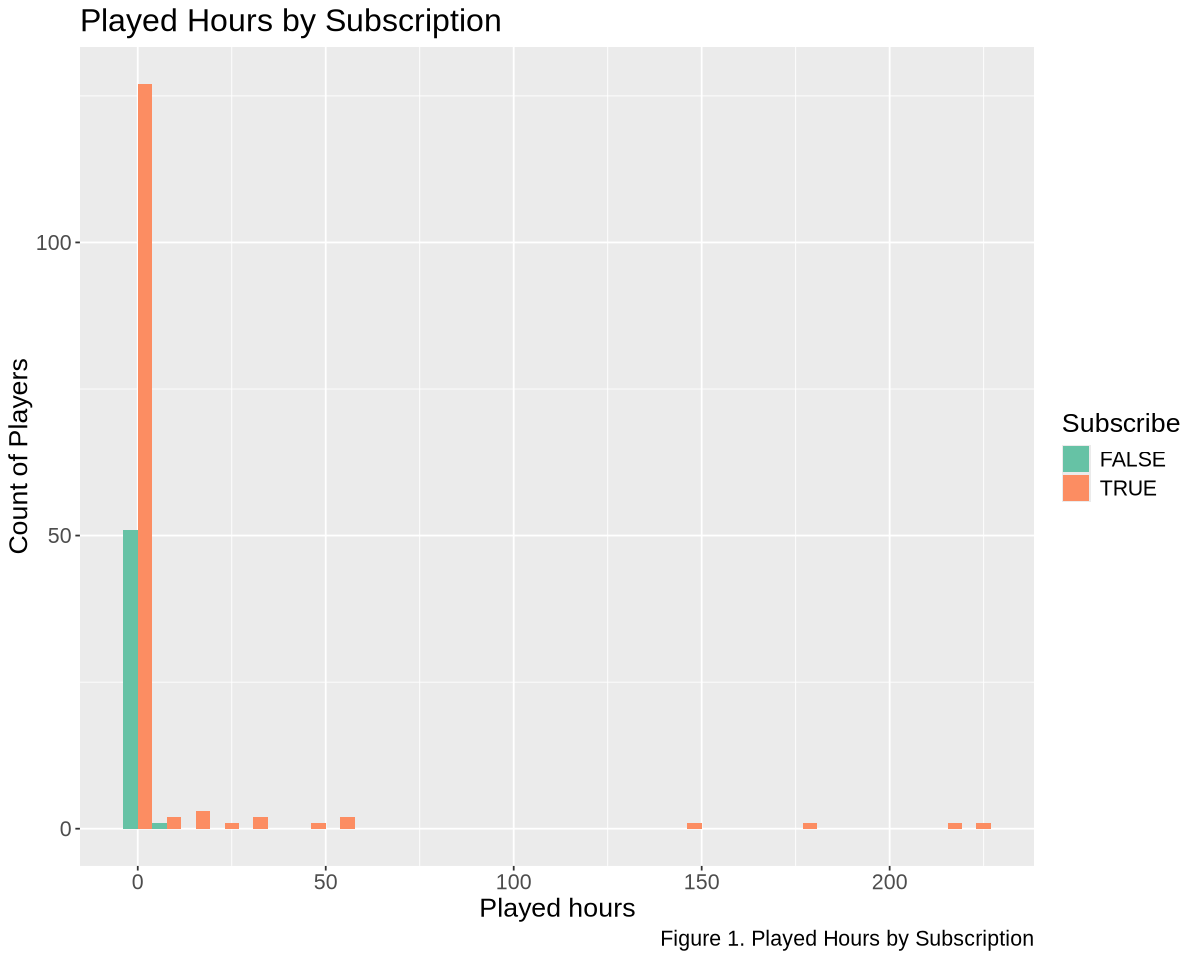

In [4]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = played_hours, fill = subscribe)) +
geom_histogram(position = "dodge", bins_width=5) +
labs(title = "Played Hours by Subscription",
       x = "Played hours", y = "Count of Players", fill = "Subscribe", caption = "Figure 1. Played Hours by Subscription") +
theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Set2')

- **Figure 1:**  The histogram shows that the majority of players have low 
played hours, under 50 hours, and all of the non-subscribers are in this group. Additionally, the proportion 
of subscribers in this group is 75%. However, for the minority of players, those who play longer,
over 50 hours, subscription rates are significantly higher, nearly 100%.

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = experience, fill = subscribe)) +
  geom_bar(position = "dodge") +
  labs(title = "Experience by Subscription Status",
       x = "Experience", y = "Count of Players", fill = "Subscribe", caption = "Figure 2. Experience by Subscription Status") +
  theme_minimal() + theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Pastel2')

- **Figure 2:**  The chart compares player counts across experience levels by subscription status. In every category, subscribed players greatly outnumber non-subscribers, with the largest gap in the Amateur group and the smallest gap in the Pro group. Subscription numbers are also high among Veteran and Regular players, while the Pro group has the fewest players overall. Overall, subscribers consistently dominate across all experience levels. 

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = Age, fill = subscribe)) +
  geom_histogram(position = "dodge", bins = 5) +
  labs(title = "Age Distribution by Subscription Status",
       x = "Age (years)", y = "Count of Players", fill = "Subscribe", caption= "Figure 3. Age Distribution by Subscription Status") +
  theme_minimal() +theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Set1')

- **Figure 3:** The bar graph demonstrates that most of the players, subscribers, and non-subscribers are below 30, with subscribers accounting for the highest proportion, while a minority of them are older, with the percentage of unsubscribe significantly rising. The number of non-subscribers in the age range 30-45 has the highest percentage compared to other age range.

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggplot(clean_players, aes(x = gender, fill = subscribe)) +
  geom_bar(position = "dodge") +
  labs(title = "Gender by Subscription Status",
       x = "Gender", y = "Count of Players", fill = "Subscribe", caption = "Gender by Subscription Status") +
  theme_minimal() + theme(text = element_text(size=16)) + scale_fill_brewer(palette = 'Accent' ) 

- **Figure 4:** The bar graph indicates that all of the genders have a higher percentage of subscribers, with the highest proportion in "Male". Additionally, the number of players of "Male" is the highest, followed by "Female" and "Other".

**Data analysis**

From the exploratory data analysis, we could see that in Figure 1, all non-subscribers played below 50 hours, and in the higher-played-hour groups, all of them are subscribers. This pattern shows that the played hours is not a good predictor, since nearly everyone has low played hours, under 50, making subscribers and non-subscribers look almost the same. Only a few extreme outliers exist, which distort KNN distances. There is also no clear separation for classification in this case. Therefore, played hours is not a good predictor, so we just use "experience", "age", and "gender" as predictors in the analysis. This also answers the specific question we listed above.

Method
-

We will use KNN classification with the response variable being “subscribe”, and explanatory variables (predictors) being “experience”, “age”, and “gender”. The first reason for this is that our response variable, “subscribe”, is classified as true or false, which is favourable for KNN classification. Secondly, KNN determines the class of a new observation (subscribe or not) by examining the k nearest data points, making it especially suitable for exploring relationships between multiple behavioural and demographic factors such as age, experience, and gender in this situation. Additionally, KNN classification is an intuitive, non-parametric method that can classify whether a player subscribes to a game-related newsletter based on similarities in player characteristics and behaviours. Compared to KNN or linear regression models, which work effectively on numeric value prediction, KNN classification is the better choice to answer the broad question and question of interest we have chosen. 


## Gender(one hot encoding)

In [6]:
clean_players_gender <- clean_players|> mutate(gender = as.factor(gender)) #one hot encoding requires it to be in factor form
gender_matrix <- model.matrix(~ gender-1, data = clean_players) # ~gender -1 means I change gender into numeric form
gender_players <- clean_players |>
  bind_cols(as_tibble(gender_matrix)) # change from matrix form to table form
head(gender_players)

experience,subscribe,played_hours,gender,Age,genderOther,genderFemale,genderMale
<chr>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
Pro,TRUE,30.3,Male,9,0,0,1
Veteran,TRUE,3.8,Male,17,0,0,1
Veteran,FALSE,0.0,Male,17,0,0,1
Amateur,TRUE,0.7,Female,21,0,1,0
Regular,TRUE,0.1,Male,21,0,0,1
Amateur,TRUE,0.0,Female,17,0,1,0


In [7]:
set.seed(1123) # set. seed function makes sure you will obtain the exact same sequence of "random" numbers every time you run the code, the number inside is arbitary
# split
gender_split <- initial_split(gender_players, prop = 0.75, strata = subscribe)
gender_train <- training(gender_split)
gender_test <- testing(gender_split)

# recipe
gender_recipe <- recipe(subscribe ~ genderOther + genderFemale+ genderMale, data = gender_train) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

In [8]:
# specification
gender_spec_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

# k-values
gender_ks <- tibble(neighbors = 1:20)

# v-fold
gender_vfold <- vfold_cv(gender_train, v = 5, strata = subscribe)

In [9]:
# workflow with validation
gender_fit <- workflow() |>
  add_recipe(gender_recipe) |>
  add_model(gender_spec_tune) |>
  tune_grid(resamples = gender_vfold, grid = gender_ks) 

# accuracy
gender_tune_accuracy <- gender_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)
head(gender_tune_accuracy)

neighbors,mean
<int>,<dbl>
17,0.4203777
18,0.4203777
19,0.3996880
20,0.3996880
13,0.3789984
14,0.3789984


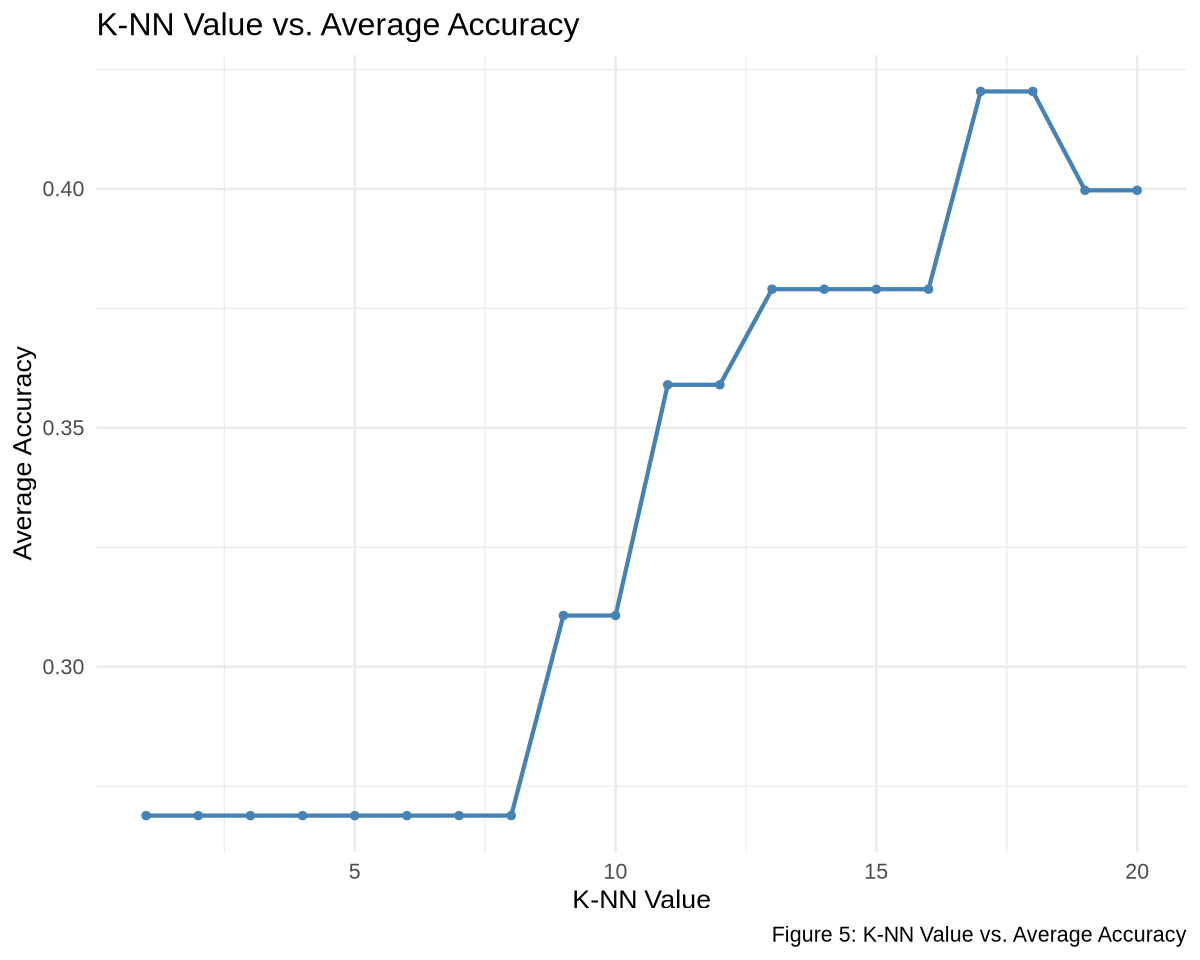

In [11]:
ggplot(gender_tune_accuracy, aes(x = neighbors, y = mean)) +
  geom_line(linewidth = 1.2, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  labs(x = "K-NN Value", y = "Average Accuracy", title = "K-NN Value vs. Average Accuracy", caption = "Figure 5: K-NN Value vs. Average Accuracy") +
  theme_minimal(base_size = 16)

**Figure 5:** Accuracy results depending on the tuning of the K-NN model. With the different K-NN values on the x-axis and the mean of the accuracy on the y-axis. Plot shows how maximum accuracy is achieved with n = 17.

In [ ]:
gender_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 17) |>
  set_engine("kknn") |>
  set_mode("classification")

gender_recipe <- recipe(subscribe ~ genderOther + genderFemale+ genderMale, data = gender_train) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

In [ ]:
# workflow with validation
gender_vfold <- vfold_cv(gender_test, v = 5, strata = subscribe)

gender_fit <- workflow() |>
  add_recipe(gender_recipe) |>
  add_model(gender_spec) |>
  fit(data = gender_train)

In [ ]:
gender_test_predictions <- predict(gender_fit, gender_test) |>
  bind_cols(gender_test)

In [ ]:
confusion_gender <- data.frame(
  truth = gender_test_predictions$subscribe,
  estimate = gender_test_predictions$.pred_class)

confusion_gender_result <- conf_mat(
  data = confusion_gender,
  truth = "truth",
  estimate = "estimate")

confusion_gender_result

In [ ]:
gender_table <- confusion_gender_result$table
gender_table_tidy <- as_tibble(gender_table)
colnames(gender_table_tidy) <- c("Prediction", "Truth", "n")

In [ ]:
ggplot(gender_table_tidy, aes(x = Truth, y = Prediction)) +
  geom_tile(color = "black",size = 1,fill="white") + 
  theme_minimal() +
geom_text(aes(label = n), color = "black", size = 6) +  
  labs(title = "Confusion Gender Matrix",
    x = "True Class",
    y = "Predicted Class",
    fill = "Count") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),  
    axis.text.y = element_text(angle = 0, size = 16),  
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold"))  

In [ ]:
gender_accuracy <-gender_test_predictions|>
  metrics(truth = subscribe, estimate = .pred_class) |>
 filter(.metric == "accuracy")
gender_accuracy

In [ ]:
gender_precision <- precision(data = confusion_gender,truth = "truth", estimate = "estimate", event_level = "second")
gender_precision

In [ ]:
gender_recall <- recall(data = confusion_gender,truth = "truth", estimate = "estimate", event_level = "second")
gender_recall

### Analysis

Our prediction analysis examined whether a player’s gender could help predict the probability they’d subscribe to the newsletter. The bar graph we generated below, which plots subscription status on the x-axis and uses colour to represent gender, provides an immediate visual prediction: across all three gender groups (“Male”, “Female”, and “Other”), the proportion of players who subscribe and do not subscribe is extremely similar. Thus, we predicted that a player’s gender had no impact on the probability of them subscribing to the newsletter.

This prediction was vindicated by the results. After encoding gender using one-hot encoding (since it is a nominal variable with no natural numeric order), the model achieved only a 32% accuracy rate, confirming that gender alone carries little predictive value.

Given this extremely low accuracy, we excluded gender from our final set of predictor variables. In addition, in terms of precision and recall, there may be many false negative predictions, since the dataset is imbalanced and has a higher amount of observations with subscription. As a result, the recall will be lower and the precision will be higher, so we don’t take these measurements into account for conclusion.

## Age (ordinal encoding)

In [12]:
head(clean_players)

experience,subscribe,played_hours,gender,Age
<chr>,<fct>,<dbl>,<fct>,<dbl>
Pro,TRUE,30.3,Male,9
Veteran,TRUE,3.8,Male,17
Veteran,FALSE,0.0,Male,17
Amateur,TRUE,0.7,Female,21
Regular,TRUE,0.1,Male,21
Amateur,TRUE,0.0,Female,17


In [13]:
set.seed(1123)
age_split <- initial_split(clean_players, prop = 0.75, strata = subscribe) 
age_train <- training(age_split)
age_test <- testing(age_split)

In [14]:
age_recipe <- recipe(subscribe ~ Age, data = age_train) |>
  step_dummy(all_nominal(), -all_outcomes()) |>  # Convert categorical variables to dummy variables, ensure that it's all numeric before scaling
  step_scale(all_numeric(), -all_outcomes())

In [15]:
age_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

age_ks <- tibble(neighbors = 1:20)

In [16]:
age_tune_vfold <- vfold_cv(age_train, v = 5, strata = subscribe)

In [17]:

age_tune_fit <- workflow() |>
  add_recipe(age_recipe) |>
  add_model(age_tune) |>
  tune_grid(resamples = age_tune_vfold, grid = age_ks) 

In [18]:

age_tune_accuracy <- age_tune_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)
head(age_tune_accuracy)

neighbors,mean
<int>,<dbl>
19,0.6835140
20,0.6766174
18,0.5108539
17,0.5039573
4,0.5034647
7,0.4972906


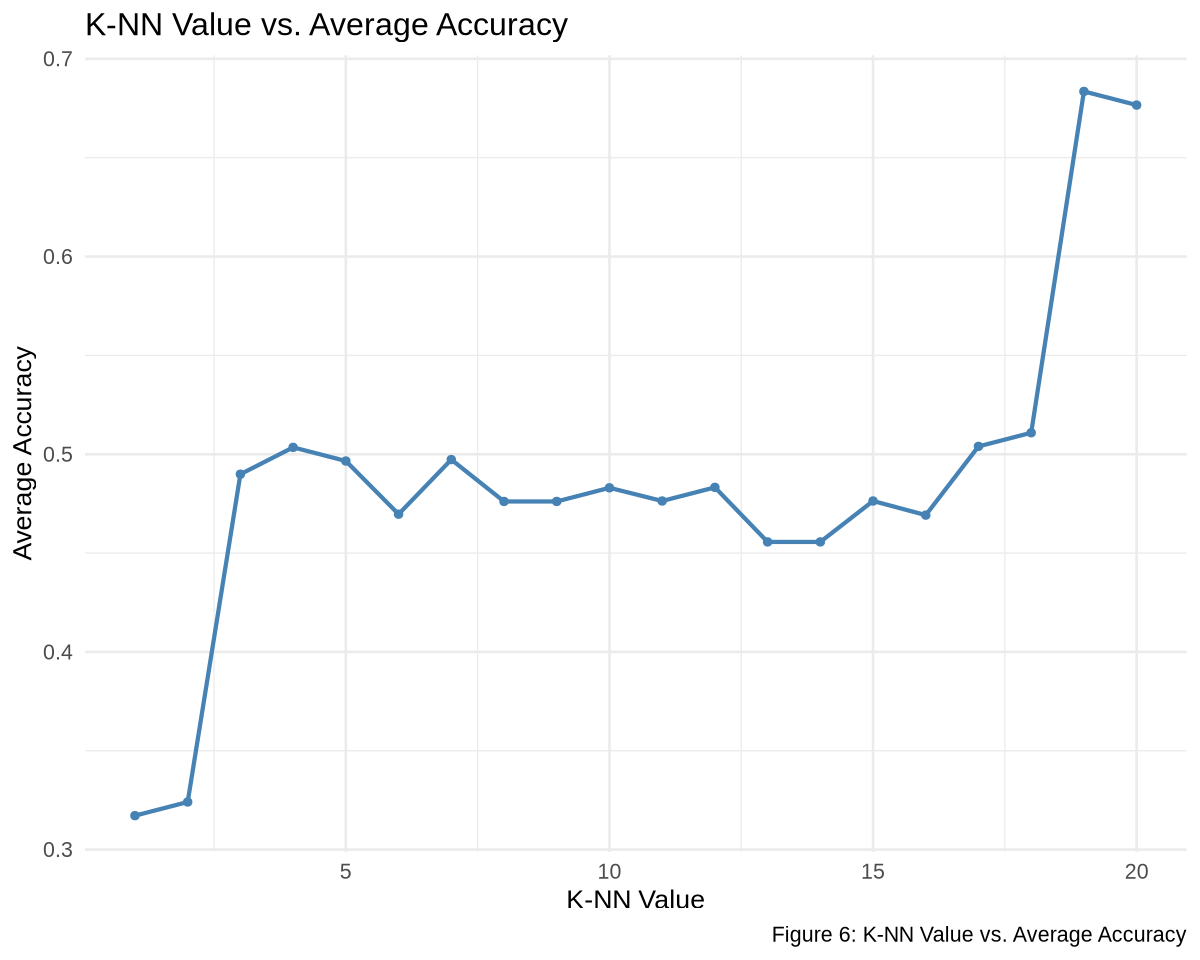

In [19]:
ggplot(age_tune_accuracy, aes(x = neighbors, y = mean)) +
  geom_line(linewidth = 1.2, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  labs(x = "K-NN Value", y = "Average Accuracy", title = "K-NN Value vs. Average Accuracy", caption = "Figure 6: K-NN Value vs. Average Accuracy") +
  theme_minimal(base_size = 16)

**Figure 6:** The average accuracy depending on the tuning of the K-NN model. K-NN value shown on x-axis, with average accuracy shown on y-axis. Visualization shows that n = 20 has the highest mean value.

In [ ]:
age_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 19) |>
  set_engine("kknn") |>
  set_mode("classification")

In [ ]:
age_fit <- workflow() |>
  add_recipe(age_recipe) |>
  add_model(age_spec) |>
 fit(data = age_train)

age_test_predictions <- predict(age_fit, age_test) |>
  bind_cols(age_test)
head(age_test_predictions)

In [ ]:
confusion_age <- data.frame(
  truth = age_test_predictions$subscribe,
  estimate = age_test_predictions$.pred_class)

confusion_age_result <- conf_mat(
  data = confusion_age,
  truth = "truth",
  estimate = "estimate")

confusion_age_result

In [ ]:
age_table <- confusion_age_result$table
age_table_tidy <- as_tibble(age_table)
colnames(age_table_tidy) <- c("Prediction", "Truth", "n")

In [ ]:
ggplot(age_table_tidy, aes(x = Truth, y = Prediction)) +
  geom_tile(color = "black",size = 1,fill="white") + #black borders
  theme_minimal() +
geom_text(aes(label = n), color = "black", size = 6) +  
  labs(title = "Confusion Age Matrix",
    x = "True Class",
    y = "Predicted Class",
    fill = "Count") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),  
    axis.text.y = element_text(angle = 0, size = 16),  
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold"))  

In [ ]:
age_accuracy <-age_test_predictions|>
  metrics(truth = subscribe, estimate = .pred_class) |>
 filter(.metric == "accuracy")
age_accuracy

In [ ]:
age_precision <-precision(data = confusion_gender,truth = "truth", estimate = "estimate", event_level = "second")
age_precision

In [ ]:
age_recall <- recall(data = confusion_gender,truth = "truth", estimate = "estimate", event_level = "second")
age_recall

### Analysis

Our analysis also examined whether a player’s age had a meaningful impact on whether they would subscribe to the newsletter or not. We generated a bar graph, which shows that younger players, especially those under 30, are more likely to subscribe to the newsletter (Figure 3). Using Figure 3 we can also see that the subscriber status is dependent on age, since the different age ranges have completely different results on the distribution of subscribers versus non-subscribers. We predicted that age is correlated with subscriber status. To prove this, we kept age as a numerical value and trained a K-NN classification model to predict subscribe, which is a boolean value. 

Our assumption was correct, the K-NN model produced an accuracy of 55%. Based on accuracy, age is the strongest predictor out of the ones we evaluated. Since younger individuals tend to be more engaged in online communities, the number of overall subscribers is higher, our visualizations show that different age groups have clear separation. These results suggest that age has the independent strength to be used as a predicator.



## Experience (ordinal encoding)

In [ ]:
experience_encoded = factor(clean_players$experience,
  levels = c("Beginner", "Amateur", "Regular", "Veteran", "Pro"),
  ordered = TRUE)
experience_numeric = as.numeric(experience_encoded)

In [ ]:
clean_experience_players <- clean_players |> mutate( experience_numeric = experience_numeric)
head(clean_experience_players)

In [ ]:
set.seed(1123)
experience_split <- initial_split(clean_experience_players, prop = 0.75, strata = subscribe)
experience_train <- training(experience_split)
experience_test <- testing(experience_split)

experience_recipe <- recipe(subscribe ~ experience_numeric, data = clean_experience_players) |>
step_dummy(all_nominal(), -all_outcomes()) |>  
  step_scale(all_numeric(), -all_outcomes())

experience_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

experience_ks <- tibble(neighbors = 1:20)

In [ ]:
experience_vfold <- vfold_cv(experience_train, v = 5, strata = subscribe)

# workflow with validation
experience_tune_fit <- workflow() |>
  add_recipe(experience_recipe) |>
  add_model(experience_tune) |>
  tune_grid(resamples = experience_vfold, grid = experience_ks) 
 
# accuracy
experience_tune_accuracy <- experience_tune_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)
head(experience_tune_accuracy)

In [ ]:
ggplot(experience_tune_accuracy, aes(x = neighbors, y = mean)) +
  geom_line(linewidth = 1.2, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  labs(x = "K-NN Value", y = "Average Accuracy", title = "K-NN Value vs. Average Accuracy", caption = "Figure 7: K-NN Value vs. Average Accuracy") +
  theme_minimal(base_size = 16)

**Figure 7:** The average accuracy depending on the tuning of the K-NN model. K-NN value shown on x-axis, with average accuracy shown on y-axis. Visualization shows that n = 20 has the highest mean value.

In [ ]:
experience_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 20) |>
  set_engine("kknn") |>
  set_mode("classification")

In [ ]:
experience_vfold <- vfold_cv(experience_train, v = 5, strata = subscribe)

In [ ]:
experience_fit <- workflow() |>
  add_recipe(experience_recipe) |>
  add_model(experience_spec) |>
  fit(data = experience_train)

In [ ]:
experience_test_predictions <- predict(experience_fit, experience_test) |>
  bind_cols(experience_test)
head(experience_test_predictions)

In [ ]:
confusion_experience <- data.frame(
  truth = experience_test_predictions$subscribe,
  estimate = experience_test_predictions$.pred_class)

confusion_experience_result <- conf_mat(
  data = confusion_experience,
  truth = "truth",
  estimate = "estimate")

confusion_experience_result

In [ ]:
experience_table <- confusion_experience_result$table
experience_table_tidy <- as_tibble(experience_table)
colnames(experience_table_tidy) <- c("Prediction", "Truth", "n")

In [ ]:
ggplot(experience_table_tidy, aes(x = Truth, y = Prediction)) +
  geom_tile(color = "black",size = 1,fill="white") + #black borders
  theme_minimal() +
geom_text(aes(label = n), color = "black", size = 6) +  
  labs(title = "Confusion Experience Matrix",
    x = "True Class",
    y = "Predicted Class",
    fill = "Count") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),  
    axis.text.y = element_text(angle = 0, size = 16),  
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold"))  

In [ ]:
experience_accuracy <- experience_test_predictions|>
  metrics(truth = subscribe, estimate = .pred_class) |>
 filter(.metric == "accuracy")
experience_accuracy

In [ ]:
experience_precision <-precision(data = confusion_experience,truth = "truth", estimate = "estimate", event_level = "second")
experience_precision

In [ ]:
experience_recall <- recall(data = confusion_experience,truth = "truth", estimate = "estimate", event_level = "second")
experience_recall

### Analysis

We explored the idea of having experience as a predicator as well. Figure 2 shows a pattern between the experience categories. Subscribers outnumber non-subscribers in each group. This pattern will affect our precision and recall values. Groups with significant differences are Amateur, Regular, and Veteran. The difference in the Pro category is less significant. Clear separation displayed in Figure 2 led us to predict that experience may have a small impact when predicting if a player is subscribed or not. We also predicted that the results may be similar to gender, where it yielded a low accuracy. To prove our assumption, we ordinally encoded experience as an ordered factor that shows the progression of the different experience categories. We kept it in the order of increasing experience, starting with Beginner, and ending with Pro. Then, we trained a K-NN classification model using the ordered factor as the predicator. Just as with the other analyses, the K-NN model was trained on one portion, and tested on a separate set to measure its accuracy.

This model produced results with an accuracy of around 47%, which disproved our previous hypothesis. These results indicate that experience may be an effective predictor if used alongside another predicator, but not as an independent one. The results create many different follow up questions, such as whether increases in experience correspond to an increase in the likelihood of a subscription, or if experience can be used alongside other variables such as age or gender to predict the subscription patterns more effectively.



## Age and Experience

In [ ]:
experience_encoded = factor(clean_players$experience,
  levels = c("Beginner", "Amateur", "Regular", "Veteran", "Pro"),
  ordered = TRUE)
experience_numeric = as.numeric(experience_encoded)

age_experience_players <- clean_players |> select(-gender,-played_hours) |> 
mutate( experience_numeric = experience_numeric) |> 
select(-experience)
head(age_experience_players)

In [ ]:
set.seed(1123)
age_experience_split <- initial_split(age_experience_players, prop = 0.75, strata = subscribe)
age_experience_train <- training(age_experience_split)
age_experience_test <- testing(age_experience_split)

In [ ]:
set.seed(1123)

age_experience_recipe <- recipe(subscribe ~ experience_numeric + Age , data = age_experience_train ) |>
step_dummy(all_nominal(), -all_outcomes()) |>  
  step_scale(all_numeric(), -all_outcomes())

In [ ]:
age_experience_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

age_experience_ks <- tibble(neighbors = 1:20)

In [ ]:
age_experience_vfold <- vfold_cv(experience_train, v = 5, strata = subscribe)

age_experience_tune_fit <- workflow() |>
  add_recipe(age_experience_recipe) |>
  add_model(age_experience_tune) |>
  tune_grid(resamples = age_experience_vfold, grid = age_experience_ks) 
 
age_experience_tune_accuracy <- age_experience_tune_fit |> collect_metrics() |>
  filter(.metric == "accuracy") |>
  select(neighbors, mean) |>
  arrange(-mean)
head(age_experience_tune_accuracy)

In [ ]:
ggplot(age_experience_tune_accuracy, aes(x = neighbors, y = mean)) +
  geom_line(linewidth = 1.2, color = "steelblue") +
  geom_point(size = 2, color = "steelblue") +
  theme_minimal(base_size = 16)

In [ ]:
age_experience_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 19) |>
  set_engine("kknn") |>
  set_mode("classification")

In [ ]:
age_experience_vfold <- vfold_cv(age_experience_train, v = 5, strata = subscribe)

age_experience_fit <- workflow() |>
  add_recipe(age_experience_recipe) |>
  add_model(age_experience_spec) |>
  fit(data = age_experience_train)

In [ ]:
age_experience_test_predictions <- predict(age_experience_fit, age_experience_test) |>
  bind_cols(age_experience_test)
head(age_experience_test_predictions)

In [ ]:
confusion_age_experience <- data.frame(
  truth = age_experience_test_predictions$subscribe,
  estimate = age_experience_test_predictions$.pred_class)

confusion_age_experience_result <- conf_mat(
  data = confusion_age_experience,
  truth = "truth",
  estimate = "estimate")

confusion_age_experience_result

In [ ]:
age_experience_table <- confusion_age_experience_result$table
age_experience_table_tidy <- as_tibble(age_experience_table)
colnames(age_experience_table_tidy) <- c("Prediction", "Truth", "n")

In [ ]:
ggplot(age_experience_table_tidy, aes(x = Truth, y = Prediction)) +
  geom_tile(color = "black",size = 1,fill="white") + 
  theme_minimal() +
geom_text(aes(label = n), color = "black", size = 6) +  
  labs(title = "Confusion Age Experience Matrix",
    x = "True Class",
    y = "Predicted Class",
    fill = "Count") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16),  
    axis.text.y = element_text(angle = 0, size = 16),  
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold"))  

In [ ]:
age_experience_accuracy <- age_experience_test_predictions|>
  metrics(truth = subscribe, estimate = .pred_class) |>
 filter(.metric == "accuracy")
age_experience_accuracy

In [ ]:
age_experience_precision <-precision(data = confusion_age_experience,truth = "truth", estimate = "estimate", event_level = "second")
age_experience_precision

In [ ]:
experience_recall <- recall(data = confusion_age_experience,truth = "truth", estimate = "estimate", event_level = "second")
experience_recall

## Conclusion

In our effort to achieve the highest possible accuracy on random test datasets, we excluded indicators that are independent of subscription status (such as gender) and tested whether combining age and experience as predictor variables would outperform using them individually. Combining the two variables did in fact produce a higher accuracy.
Another key issue in the dataset is class imbalance: there are far more subscribers than non-subscribers. When one class dominates, models tend to learn the majority class and default to predicting it more often. As we set subscription = TRUE as the thing we are predicting, using event level = “second,” the precision of each of the predictors will be high. Therefore, precision is not a reliable evaluation metric. The imbalance also caused the model to produce many false negatives, resulting in consistently low recall. For this reason, recall was also not used to evaluate model success, leaving accuracy as the most appropriate evaluation method. To increase the recall rate, the survey should try to expand its range to survey more people who aren’t subscribed to the newsletter so that the dataset is more balanced, decreasing the amount of false negatives
Because age and experience are best able to predict if someone will subscribe or not, Minecraft should focus its advertising efforts towards groups most likely to subscribe in the first place, such as those under 30. 
The results also raise an important new question: Does subscription probability rise consistently with experience, or only after certain thresholds? For example, does probability rise consistently after a player attains the Amateur rank, or after they become a Regular? Thus, we may find ways to accurately reflect experience status.


## Reference 

In [ ]:
Plaicraft. PLAICraft. (n.d.). https://plaicraft.ai/ 